## Treinamento Final Logistic Regression (pipeline do notebook 05)

Pipeline aplicado:
- Dataset: ../data/processed/carhacking_ciciov_benign_dos_aligned.csv
- Remove source == 'CARDT' and dlc < 8
- Features: id + val0..val7
- Balanceamento: BENIGN limitado a 1.000.000

Outputs salvos em: ../results/metrics/logistic_regression_final_clean/

incomplete CARDT rows removidas: 200665
sampled train/test: (200000, 9) (80000, 9)
frac=0.20 train_acc=0.97318 test_acc=0.97257
frac=0.40 train_acc=0.97393 test_acc=0.97284
frac=0.60 train_acc=0.97337 test_acc=0.97303
frac=0.80 train_acc=0.97117 test_acc=0.97091
frac=1.00 train_acc=0.97276 test_acc=0.97269
              precision    recall  f1-score   support

      BENIGN    0.93991   0.96892   0.95419     23487
         DoS    0.98249   0.98515   0.98382     15553
       Fuzzy    0.95900   0.89292   0.92478     11552
        GEAR    0.99822   1.00000   0.99911     14027
         RPM    0.99974   1.00000   0.99987     15381

    accuracy                        0.97252     80000
   macro avg    0.97587   0.96940   0.97235     80000
weighted avg    0.97267   0.97252   0.97236     80000



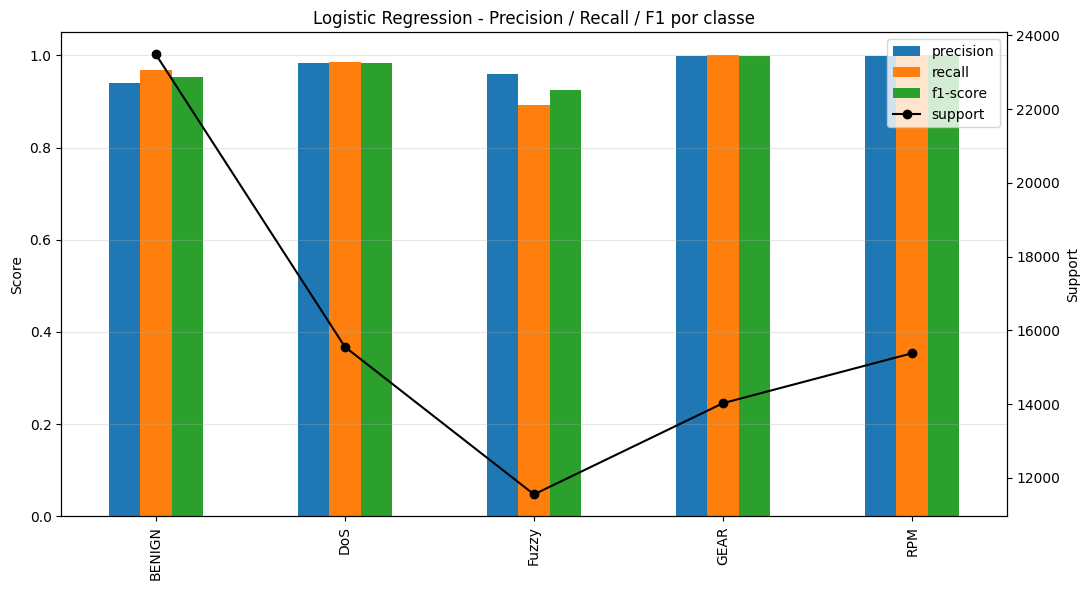

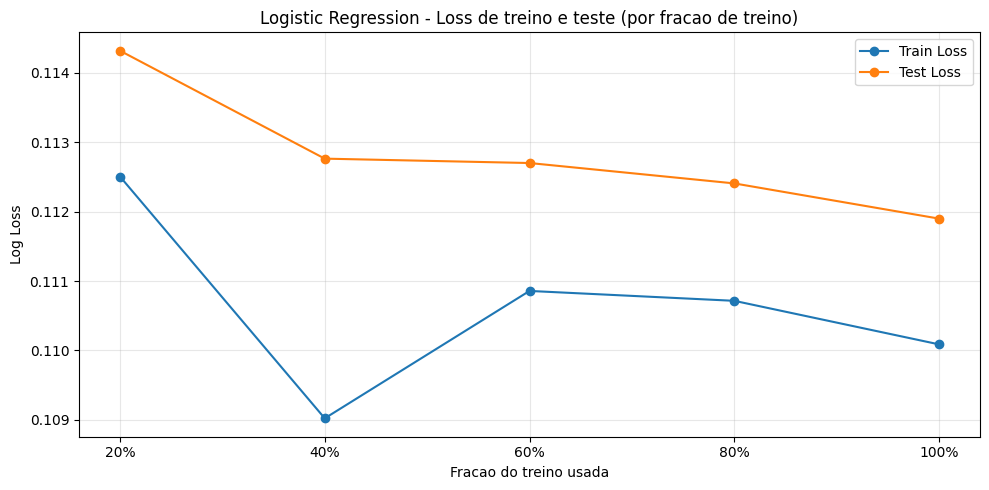

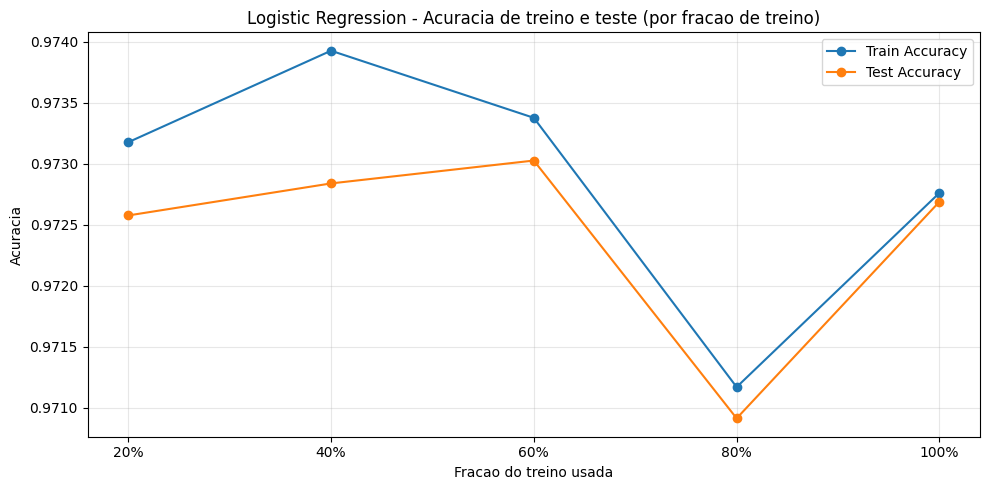

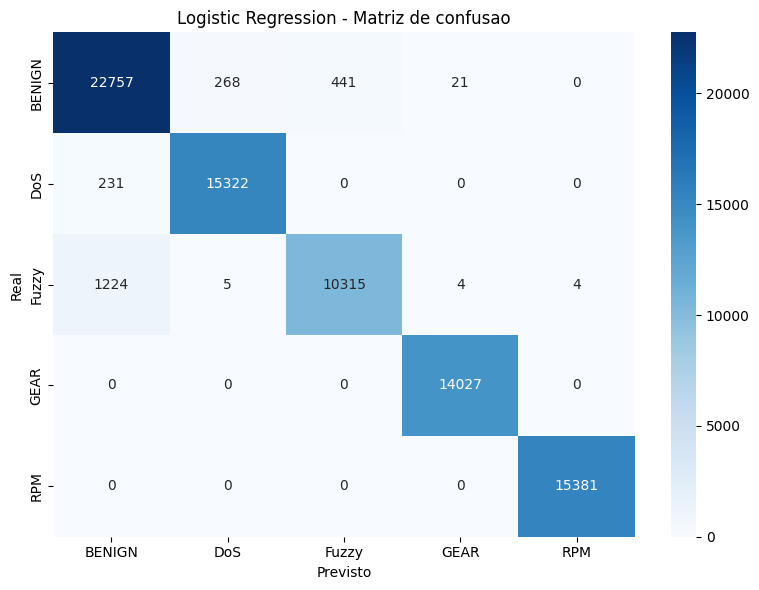

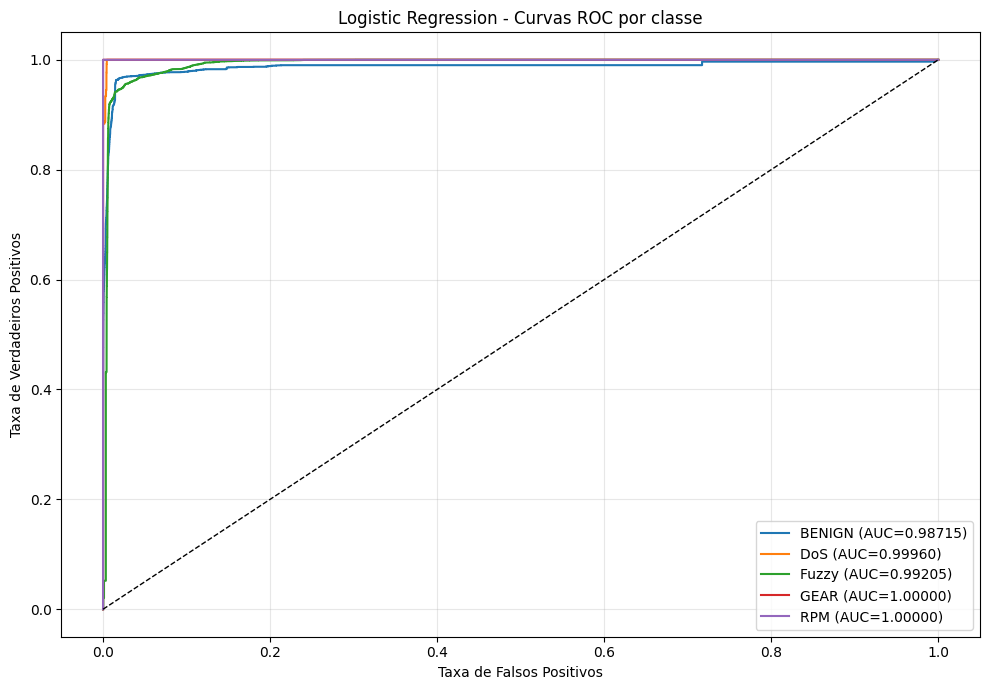

Arquivos salvos em: C:\Users\thelo\Documents\TCC\IOVT-TCC\results\metrics\logistic_regression_final_clean


In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    log_loss,
    accuracy_score,
)

RANDOM_STATE = 42
BENIGN_TARGET = 1_000_000
TRAIN_SAMPLE_MAX = 200_000
TEST_SAMPLE_MAX = 80_000
CURVE_FRAC_POINTS = 5
DATA_PATH = Path('../data/processed/carhacking_ciciov_benign_dos_aligned.csv')
OUT_DIR = Path('../results/metrics/logistic_regression_final_clean')
OUT_DIR.mkdir(parents=True, exist_ok=True)

byte_cols = [f'val{i}' for i in range(8)]

# 1) Carregar e limpar conforme melhor experimento do notebook 05
full_df = pd.read_csv(DATA_PATH)
required_cols = ['id', 'dlc'] + byte_cols + ['flag', 'source']
missing = [c for c in required_cols if c not in full_df.columns]
if missing:
    raise ValueError(f'Colunas ausentes no dataset: {missing}')

full_df = full_df[required_cols].dropna().copy()
incomplete_mask = (full_df['source'] == 'CARDT') & (full_df['dlc'] < 8)
print('incomplete CARDT rows removidas:', int(incomplete_mask.sum()))
df_no_incomplete = full_df.loc[~incomplete_mask, ['id'] + byte_cols + ['flag']].copy()

# 2) Balancear BENIGN
benign_df = df_no_incomplete[df_no_incomplete['flag'] == 'BENIGN']
attack_df = df_no_incomplete[df_no_incomplete['flag'] != 'BENIGN']
benign_sampled = benign_df.sample(n=min(BENIGN_TARGET, len(benign_df)), random_state=RANDOM_STATE)
df_balanced = pd.concat([benign_sampled, attack_df], axis=0)
df_balanced = df_balanced.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

le = LabelEncoder()
df_balanced['flag_encoded'] = le.fit_transform(df_balanced['flag'])
X = df_balanced[['id'] + byte_cols].copy()
y = df_balanced['flag_encoded'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=40
)

# Amostragem para tornar o treino viavel no conjunto grande
train_size = min(TRAIN_SAMPLE_MAX, len(X_train))
test_size = min(TEST_SAMPLE_MAX, len(X_test))
X_train, _, y_train, _ = train_test_split(
    X_train, y_train,
    train_size=train_size,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
X_test, _, y_test, _ = train_test_split(
    X_test, y_test,
    train_size=test_size,
    stratify=y_test,
    random_state=RANDOM_STATE,
)

print('sampled train/test:', X_train.shape, X_test.shape)

# 3) Curvas por fracao de treino
fractions = np.linspace(0.2, 1.0, CURVE_FRAC_POINTS)
train_loss_list, test_loss_list = [], []
train_acc_list, test_acc_list = [], []

for frac in fractions:
    n_rows = max(5000, int(len(X_train) * frac))
    idx = X_train.sample(n=n_rows, random_state=RANDOM_STATE).index
    X_sub = X_train.loc[idx]
    y_sub = y_train.loc[idx]

    model_frac = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(
            solver='lbfgs',
            max_iter=300,
            random_state=RANDOM_STATE,
        )),
    ])
    model_frac.fit(X_sub, y_sub)

    proba_sub = model_frac.predict_proba(X_sub)
    proba_test = model_frac.predict_proba(X_test)

    pred_sub = model_frac.predict(X_sub)
    pred_test = model_frac.predict(X_test)

    train_loss_list.append(log_loss(y_sub, proba_sub, labels=np.arange(len(le.classes_))))
    test_loss_list.append(log_loss(y_test, proba_test, labels=np.arange(len(le.classes_))))
    train_acc_list.append(accuracy_score(y_sub, pred_sub))
    test_acc_list.append(accuracy_score(y_test, pred_test))

    print(f'frac={frac:.2f} train_acc={train_acc_list[-1]:.5f} test_acc={test_acc_list[-1]:.5f}')

# 4) Modelo final
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        solver='lbfgs',
        max_iter=400,
        random_state=RANDOM_STATE,
    )),
])
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
y_proba = lr_model.predict_proba(X_test)

# 5) Metricas
report_text = classification_report(y_test, y_pred, target_names=le.classes_.astype(str), digits=5)
print(report_text)

report_dict = classification_report(
    y_test,
    y_pred,
    target_names=le.classes_.astype(str),
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(OUT_DIR / 'classification_report.csv', index=True)
(OUT_DIR / 'classification_report.txt').write_text(report_text, encoding='utf-8')

# 6) Grafico precision/recall/f1/support
class_rows = [c for c in le.classes_.astype(str) if c in report_df.index]
metrics_df = report_df.loc[class_rows, ['precision', 'recall', 'f1-score', 'support']].copy()

fig, ax1 = plt.subplots(figsize=(11, 6))
metrics_df[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=ax1)
ax1.set_ylim(0, 1.05)
ax1.set_ylabel('Score')
ax1.set_title('Logistic Regression - Precision / Recall / F1 por classe')
ax1.grid(axis='y', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(np.arange(len(metrics_df)), metrics_df['support'].values, color='black', marker='o', label='support')
ax2.set_ylabel('Support')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'metrics_bar.png', dpi=200)
plt.show()

# 7) Curvas de loss e acuracia
x_axis = np.arange(1, len(fractions) + 1)
labels = [f'{int(f * 100)}%' for f in fractions]

plt.figure(figsize=(10, 5))
plt.plot(x_axis, train_loss_list, marker='o', label='Train Loss')
plt.plot(x_axis, test_loss_list, marker='o', label='Test Loss')
plt.xticks(x_axis, labels)
plt.xlabel('Fracao do treino usada')
plt.ylabel('Log Loss')
plt.title('Logistic Regression - Loss de treino e teste (por fracao de treino)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'loss_curve.png', dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(x_axis, train_acc_list, marker='o', label='Train Accuracy')
plt.plot(x_axis, test_acc_list, marker='o', label='Test Accuracy')
plt.xticks(x_axis, labels)
plt.xlabel('Fracao do treino usada')
plt.ylabel('Acuracia')
plt.title('Logistic Regression - Acuracia de treino e teste (por fracao de treino)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'accuracy_curve.png', dpi=200)
plt.show()

# 8) Matriz de confusao
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Logistic Regression - Matriz de confusao')
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix.png', dpi=200)
plt.show()

# 9) Curvas ROC multiclasse
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))

plt.figure(figsize=(10, 7))
for i, cls_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls_name} (AUC={roc_auc:.5f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Logistic Regression - Curvas ROC por classe')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'roc_curves.png', dpi=200)
plt.show()

# 10) Salvar historico
history_df = pd.DataFrame({
    'fraction': fractions,
    'train_loss': train_loss_list,
    'test_loss': test_loss_list,
    'train_accuracy': train_acc_list,
    'test_accuracy': test_acc_list,
})
history_df.to_csv(OUT_DIR / 'training_history.csv', index=False)

summary = {
    'model': 'LogisticRegression',
    'data_path': str(DATA_PATH),
    'output_dir': str(OUT_DIR),
    'removed_cardt_dlc_lt_8': int(incomplete_mask.sum()),
    'train_shape': [int(X_train.shape[0]), int(X_train.shape[1])],
    'test_shape': [int(X_test.shape[0]), int(X_test.shape[1])],
    'classes': le.classes_.astype(str).tolist(),
    'final_train_acc_curve_point': float(train_acc_list[-1]),
    'final_test_acc_curve_point': float(test_acc_list[-1]),
}
(OUT_DIR / 'run_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

print(f'Arquivos salvos em: {OUT_DIR.resolve()}')